In [36]:
from pathlib import Path
import kagglehub
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
import random
import os

In [37]:
# Download the dataset locally
dataset_dir = Path(kagglehub.dataset_download("andrewmvd/dog-and-cat-detection"))
print(f"Dataset downloaded to: {dataset_dir.resolve()}")

# Preview top-level files/folders.
for item in sorted(dataset_dir.iterdir()):
    print(f"- {item.name}")

Dataset downloaded to: C:\Users\kiann\.cache\kagglehub\datasets\andrewmvd\dog-and-cat-detection\versions\1
- annotations
- images


In [38]:
from pathlib import Path
import random
import pandas as pd
from kagglehub import dataset_download
# Try to import refactored utilities from repo; fallback to definitions below
try:
    from src.data_processing import resize_and_pad_image, transform_bbox, process_record, split_train_val, visualize_sample
except Exception:
    from PIL import Image
    import matplotlib.pyplot as plt
    def resize_and_pad_image(img: Image.Image, size=(112,112)):
        W,H=size; w,h=img.size
        scale=min(W/w,H/h)
        new_w=max(1,int(round(w*scale))); new_h=max(1,int(round(h*scale)))
        img_resized=img.resize((new_w,new_h),Image.BILINEAR)
        pad_left=(W-new_w)//2; pad_top=(H-new_h)//2
        canvas=Image.new("RGB",(W,H),(0,0,0)); canvas.paste(img_resized,(pad_left,pad_top))
        return canvas,scale,pad_left,pad_top
    def transform_bbox(bbox,scale,pad_left,pad_top):
        xmin,ymin,xmax,ymax=bbox
        return (max(0,int(round(xmin*scale+pad_left))),
                max(0,int(round(ymin*scale+pad_top))),
                max(0,int(round(xmax*scale+pad_left))),
                max(0,int(round(ymax*scale+pad_top))))
    def process_record(image_path, bbox, out_path, size=(112,112)):
        img=Image.open(image_path).convert("RGB")
        orig_w,orig_h=img.size
        canvas,scale,pad_left,pad_top=resize_and_pad_image(img,size=size)
        xmin,ymin,xmax,ymax=transform_bbox(bbox,scale,pad_left,pad_top)
        out_path.parent.mkdir(parents=True,exist_ok=True)
        canvas.save(out_path)
        return {"image_path":str(out_path),"orig_w":orig_w,"orig_h":orig_h,"scale":float(scale),
                "pad_left":int(pad_left),"pad_top":int(pad_top),"xmin":int(xmin),"ymin":int(ymin),
                "xmax":int(xmax),"ymax":int(ymax)}
    from sklearn.model_selection import train_test_split
    def split_train_val(df, stratify_col="label", val_frac=0.2, random_state=42):
        if stratify_col in df.columns:
            t,v = train_test_split(df, test_size=val_frac, stratify=df[stratify_col], random_state=random_state)
        else:
            t,v = train_test_split(df, test_size=val_frac, random_state=random_state)
        return t.reset_index(drop=True), v.reset_index(drop=True)
    def visualize_sample(image_path, bbox, show=True, save_path=None):
        from PIL import Image
        import matplotlib.pyplot as plt
        img=Image.open(image_path).convert("RGB")
        fig,ax=plt.subplots(1); ax.imshow(img)
        xmin,ymin,xmax,ymax=bbox
        rect=plt.Rectangle((xmin,ymin),xmax-xmin,ymax-ymin,linewidth=2,edgecolor="r",facecolor="none")
        ax.add_patch(rect); ax.axis("off")
        if save_path: fig.savefig(save_path,bbox_inches="tight",pad_inches=0)
        if show: plt.show()
        plt.close(fig)

In [39]:
from pathlib import Path
dataset_dir = Path(dataset_download("andrewmvd/dog-and-cat-detection"))
print("Dataset dir:", dataset_dir.resolve())
for p in sorted(dataset_dir.iterdir()):
    print("-", p.name)

Dataset dir: C:\Users\kiann\.cache\kagglehub\datasets\andrewmvd\dog-and-cat-detection\versions\1
- annotations
- images


In [40]:
for p in dataset_dir.rglob("*.csv"):
    df_check = pd.read_csv(p, nrows=0) # Only reads header
    print(f"File: {p.name} | Columns: {list(df_check.columns)}")

In [41]:
# 1. Find all XML files
xml_files = list(dataset_dir.rglob("*.xml"))
print(f"Found {len(xml_files)} XML files.")

data = []

# 2. Loop through each file and extract info
for xml_path in xml_files:
    print(f"Processing: {xml_path}", end='')
    print("\r", end="")
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # Get filename (sometimes stored inside the XML)
    file_name = root.find('filename').text
    
    # Each XML can have multiple objects (bounding boxes)
    for obj in root.findall('object'):
        label = obj.find('name').text
        bbox = obj.find('bndbox')

        data.append({
            'filename': file_name,
            'class': label,
            'xmin': int(bbox.find('xmin').text),
            'ymin': int(bbox.find('ymin').text),
            'xmax': int(bbox.find('xmax').text),
            'ymax': int(bbox.find('ymax').text)
        })
    
    # clear console line after processing each file
    print("\033[F\033[K", end='')


# 3. Create the DataFrame your original code was looking for
df = pd.DataFrame(data)
print("Loaded annotations shape:", df.shape)
print(df.head())

Found 3686 XML files.
Loaded annotations shape: (3687, 6)agglehub\datasets\andrewmvd\dog-and-cat-detection\versions\1\annotations\Cats_Test999.xmll
            filename class  xmin  ymin  xmax  ymax
0     Cats_Test0.png   cat    83    29   197   142
1     Cats_Test1.png   dog   128    22   240   222
2    Cats_Test10.png   dog   157    56   264   116
3   Cats_Test100.png   cat   142   145   206   209
4  Cats_Test1000.png   cat    36    14   289   312


In [42]:
# Expected final columns: image, label, xmin, ymin, xmax, ymax
colmap = {}
if 'file_name' in df.columns and 'label' in df.columns: colmap['file_name'] = 'image'
if 'image' not in df.columns: colmap[df.columns[0]] = 'image'
if 'class' in df.columns: colmap['class'] = 'label'
if 'x1' in df.columns: colmap['x1'] = 'xmin'
if 'y1' in df.columns: colmap['y1'] = 'ymin'
if 'x2' in df.columns: colmap['x2'] = 'xmax'
if 'y2' in df.columns: colmap['y2'] = 'ymax'
df = df.rename(columns=colmap)
required = {'image','label','xmin','ymin','xmax','ymax'}
if not required.issubset(set(df.columns)):
    raise ValueError(f"Annotations missing required columns: {required - set(df.columns)}")
# make image paths absolute if necessary
df['image'] = df['image'].apply(lambda p: str((dataset_dir / p) if not Path(p).is_absolute() else Path(p)))

In [43]:
train_df, val_df = split_train_val(df, stratify_col='label', val_frac=0.2, random_state=42)
print("Train/Val sizes:", len(train_df), len(val_df))

Train/Val sizes: 2949 738


In [44]:
# check if we have any overlap between train and val sets
overlap = set(train_df['image']) & set(val_df['image'])
print(f"Number of overlapping images: {len(overlap)}")
# should be 0

Number of overlapping images: 0


In [48]:
# Define output paths
out_dir = Path("data/processed")
train_out_dir = out_dir / "train"
val_out_dir = out_dir / "val"

# Ensure directories exist
train_out_dir.mkdir(parents=True, exist_ok=True)
val_out_dir.mkdir(parents=True, exist_ok=True)

train_rows = []
val_rows = []

def process_df_rows(df_in, dst_dir, rows_out):
    print(f"Processing {len(df_in)} rows for {dst_dir.name}...")
    for i, r in df_in.iterrows():
        # Correctly locate the image in the 'images' subfolder
        img_path = dataset_dir / "images" / Path(r['image']).name
        
        # Safety check: skip if the image file is missing
        if not img_path.exists():
            continue
            
        # Define destination path and current bbox
        fname = img_path.name
        dst = dst_dir / fname
        bbox = (float(r['xmin']), float(r['ymin']), float(r['xmax']), float(r['ymax']))
        
        # process_record: Resizes to 112x112, pads, saves image, and returns updated bbox
        meta = process_record(img_path, bbox, dst, size=(112, 112))
        
        # Add the label back to the metadata
        meta['label'] = r['label']
        rows_out.append(meta)

# 2. Run processing for both splits
process_df_rows(train_df, train_out_dir, train_rows)
process_df_rows(val_df, val_out_dir, val_rows)

# 3. Create new DataFrames and save to CSV
train_processed_df = pd.DataFrame(train_rows)
val_processed_df = pd.DataFrame(val_rows)

train_processed_df.to_csv(out_dir / "train.csv", index=False)
val_processed_df.to_csv(out_dir / "val.csv", index=False)

print(f"Successfully saved {len(train_processed_df)} train and {len(val_processed_df)} val records.")
print(f"Processed data located at: {out_dir.resolve()}")

Processing 2949 rows for train...
Processing 738 rows for val...
Successfully saved 2949 train and 738 val records.
Processed data located at: C:\Users\kiann\Documents\.Education\UU\Courses\INFOCV\Assignments\04_UU_CV_Dog_Cat_Object_Detection\notebooks\data\processed


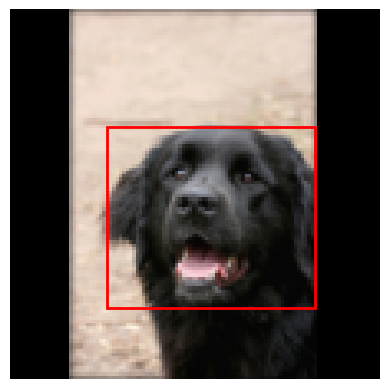

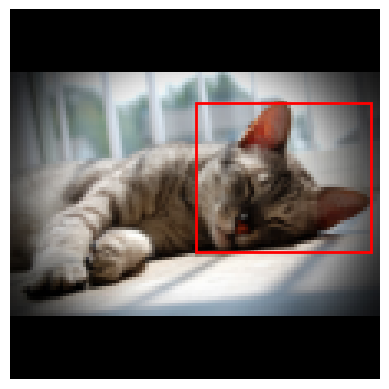

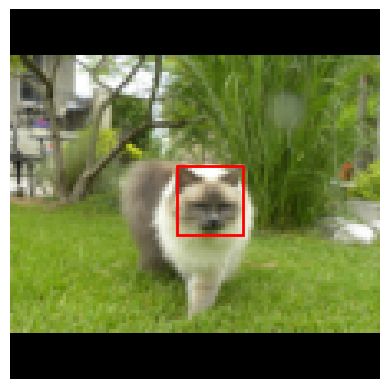

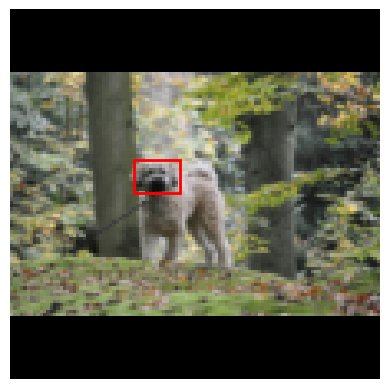

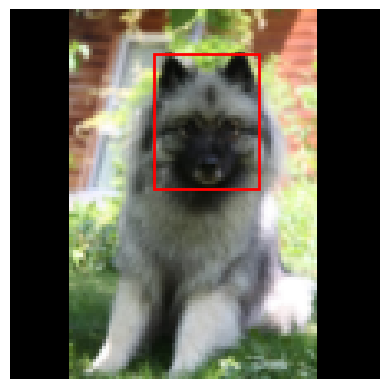

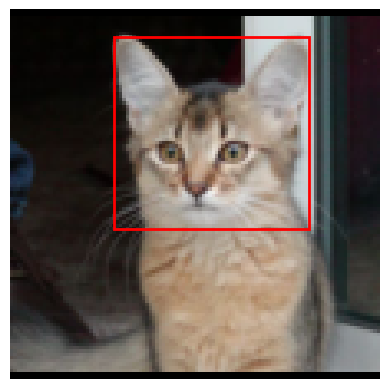

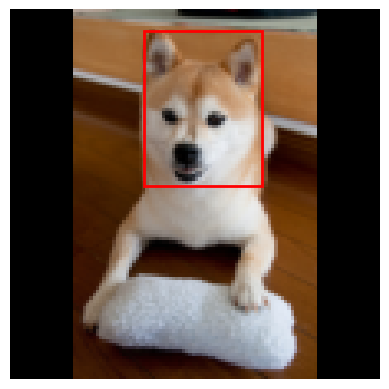

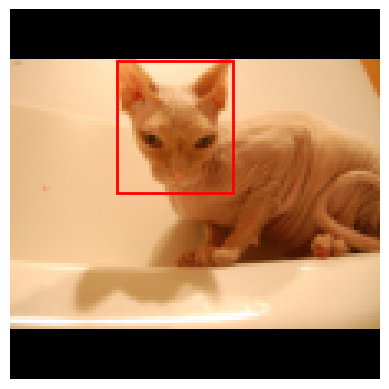

In [49]:
proc_train_csv = Path("data/processed/train.csv")
proc_df = pd.read_csv(proc_train_csv)
for i in random.sample(range(len(proc_df)), min(8, len(proc_df))):
    row = proc_df.iloc[i]
    img_p = Path(row['image_path'])
    bbox = (int(row['xmin']), int(row['ymin']), int(row['xmax']), int(row['ymax']))
    visualize_sample(img_p, bbox, show=True)